Red convolucional y transfer learning
Objetivo: Aplicar la técnica de transfer learning utilizando un modelo preentrenado para clasificar imágenes de perros y gatos.
El objetivo es demostrar cómo un modelo que ya ha aprendido características generales del dominio visual puede reutilizar ese conocimiento para una nueva tarea, logrando un entrenamiento más rápido, con mayor precisión y usando menos datos.

In [ ]:
!pip install torchinfo

In [ ]:
# Importar librerías
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import random
from PIL import Image
import cv2
import glob
from tqdm.auto import tqdm # Loading bar
import os
import zipfile
plt.style.use('ggplot') # Estilo ggplot

import os
import shutil

# Importar paquetes para evaluación
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Importar paquetes de pytorch
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

# Importar paquetes de  torchvision packages
import torchvision
from torchinfo import summary
from torchvision import datasets
from torchvision import transforms

## Descargar conjunto de datos

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data.zip


In [ ]:
local_zip = 'data.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/data')
zip_ref.close()

In [ ]:
data_path = Path("/content/data/data/")
image_path = data_path/"train"

In [ ]:
# Contar cantidad de imágenes en las carpetas
for dirpath, dirnames, filenames in os.walk(image_path):
    print(f"Hay {len(filenames)} imágenes en '{dirpath}'.")

Hay 0 imágenes en '/content/data/data/train'.
Hay 2501 imágenes en '/content/data/data/train/dogs'.
Hay 2501 imágenes en '/content/data/data/train/cats'.


## Preparar el conjunto de datos


### Separar el conjunto de datos

In [ ]:
# Carpetas originales con clases mezcladas
base_dir = Path("/content/data/data/train")

cats_dir = base_dir / "cats"
dogs_dir = base_dir / "dogs"

# Carpetas destino
train_dest = Path("/content/data/data_split/train")
test_dest  = Path("/content/data/data_split/test")

# Crear estructura de carpetas
(train_dest / "cats").mkdir(parents=True, exist_ok=True)
(train_dest / "dogs").mkdir(parents=True, exist_ok=True)
(test_dest / "cats").mkdir(parents=True, exist_ok=True)
(test_dest / "dogs").mkdir(parents=True, exist_ok=True)

def split_class(src_dir, class_name, split_ratio=0.8):
    """Divide imágenes de una clase en train/test"""
    images = [p for p in src_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    random.shuffle(images)

    cut = int(len(images) * split_ratio)
    train_imgs = images[:cut]
    test_imgs = images[cut:]

    # Copiar
    for img in train_imgs:
        shutil.copy2(img, train_dest / class_name)
    for img in test_imgs:
        shutil.copy2(img, test_dest / class_name)

    print(f"{class_name}: Train={len(train_imgs)}, Test={len(test_imgs)} (Total={len(images)})")

# Dividir las clases
split_class(cats_dir, "cats")
split_class(dogs_dir, "dogs")

cats: Train=2000, Test=501 (Total=2501)
dogs: Train=2000, Test=501 (Total=2501)


In [ ]:
# Definir ruta de imágenes de entrenamiento y prueba
test_dest, train_dest

(PosixPath('/content/data/data_split/test'),
 PosixPath('/content/data/data_split/train'))

### Visualizar imagen aleatoria

Ruta de la imagen: /content/data/data_split/test/dogs/dog.243.jpg
Clase: dogs
Altura de la imagen: 358
Base de la altura: 461


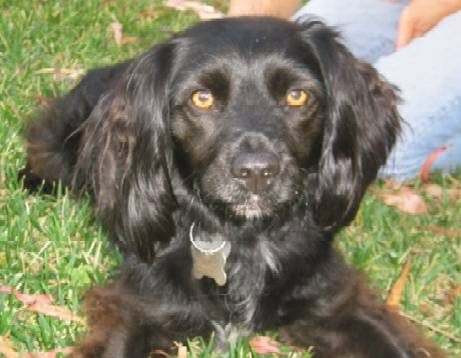

In [ ]:
# Obtener todas las rutas de las imagenes en la lista(* significa cualquier combinación)
image_path_list = list(test_dest.glob("*/*.jpg"))
# Obtener una ruta aleatoria
random_image_path = random.choice(image_path_list)
# Obtener la clase de la imagen a partir del nombre de la ruta donde está almacenada
image_class = random_image_path.parent.stem

# Abrir imagen
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Ruta de la imagen: {random_image_path}")
print(f"Clase: {image_class}")
print(f"Altura de la imagen: {img.height}")
print(f"Base de la altura: {img.width}")
img

### Preparar el conjunto de datos  
Consultar:  
-[Models and pretrained weights](https://pytorch.org/vision/main/models.html#)  
-[EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks](https://arxiv.org/pdf/1905.11946.pdf)

In [ ]:
# Obtener los pesos de u modelo preentrenado
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # .DEFAULT= mejores pesos disponibles de un modelo preentrenado
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [ ]:
# Observar las transformaciones que se le realizaron al modelo preentrenado
transformations = weights.transforms()
transformations

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [ ]:
train_data = datasets.ImageFolder(root=train_dest, # target folder of images
                                  transform=transformations) # transforms to perform on data (images)

test_data = datasets.ImageFolder(root=test_dest,
                                 transform=transformations)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 4000
    Root location: /content/data/data_split/train
    StandardTransform
Transform: ImageClassification(
               crop_size=[224]
               resize_size=[256]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BICUBIC
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 1002
    Root location: /content/data/data_split/test
    StandardTransform
Transform: ImageClassification(
               crop_size=[224]
               resize_size=[256]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BICUBIC
           )


In [ ]:
# Tamaño del conjunto de datos de entrenamiento y prueba
len(train_data), len(test_data)

(4000, 1002)

In [ ]:
# Nombre de las clases
class_names = train_data.classes
class_names

['cats', 'dogs']

In [ ]:
# Podemos tener las clases en un diccionario
class_dict = train_data.class_to_idx
class_dict

{'cats': 0, 'dogs': 1}

In [ ]:
# Obtener un elemento del conjunto de datos
img, _ = train_data[0]
print(f"Tamaño de la imagen: {img.shape}") # Channels First  (NCHW)]

Tamaño de la imagen: torch.Size([3, 224, 224])


In [ ]:
# Rango de las imágenes
print(f"Valor máximo del tensor: {img.max()}")
print(f"Valor mínimo del tensor: {img.min()}")

Valor máximo del tensor: 2.3235294818878174
Valor mínimo del tensor: -2.1007792949676514


#### Preparación del DataLoader  

In [ ]:
BATCH_SIZE = 64
train_dataloader = DataLoader(dataset = train_data,
                               batch_size = BATCH_SIZE,
                               shuffle = True)

In [ ]:
test_dataloader = DataLoader(dataset = test_data,
                               batch_size = BATCH_SIZE,
                               shuffle = False)

In [ ]:
print(f"Número de batches en el train loader: {len(train_dataloader)} batches de {BATCH_SIZE} imágenes cada uno")
print(f"Número de batches en el validation loader: {len(test_dataloader)} batches de {BATCH_SIZE} imágenes cada uno")

Número de batches en el train loader: 63 batches de 64 imágenes cada uno
Número de batches en el validation loader: 16 batches de 64 imágenes cada uno


In [ ]:
# Verificar que hay dentro del DataLoader
train_batches, labels = next(iter(train_dataloader))
print(train_batches.shape)
print(f"Label shape: {labels.shape}")

torch.Size([64, 3, 224, 224])
Label shape: torch.Size([64])


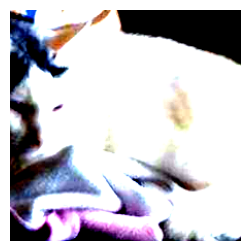

In [ ]:
# Visualizar una imagen aleatoria del batch
random_idx = random.randint(0, len(train_batches)-1)
img_batch = train_batches[random_idx]
fig = plt.figure(figsize=(3,3))
plt.imshow(img_batch.squeeze().permute(1, 2, 0))
plt.axis("off")
plt.show()

In [ ]:
# Configuración de CPU o GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cpu


## Definir arquitectura del modelo

In [ ]:
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 131MB/s] 


In [ ]:
# Despliega un resumen del modelo
summary(model=model,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [ ]:
# Observar que en la ultima capa hay 1000 neuronas en la capa de salida
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# Congelamos todos los pesos  (extraccion de caracteristicas)
# Para congelar los pesos en la sección de características requerimos poner requires_grad=False
for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
# Recrear la sección del calsificador con los datos de nuestro modelo (1 neurona a la salida)
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2),
    torch.nn.Linear(in_features=1280,
                    out_features=1,
                    bias=True)).to(device)

In [ ]:
# Volver a ver el resumen del modelo
summary(model,
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [ ]:
# Observar que ahora hay 1 neurona en la capa de salida
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
# Probar clasificador con entrada dummy
dummy_x = torch.rand([1,3,224,224]).to(device)
print(f"Tamaño del vector de entrada del clasificador: {dummy_x.size()}")
model.eval()
with torch.inference_mode():
    dummy_out = model(dummy_x)
print(f"Salida del clasificador: {dummy_out.shape}")
print(f"Salida del clasificador: {dummy_out}")

Tamaño del vector de entrada del clasificador: torch.Size([1, 3, 224, 224])
Salida del clasificador: torch.Size([1, 1])
Salida del clasificador: tensor([[0.0479]])


## Entrenamiento del modelo

### Definir función de costo y optimizador

In [ ]:
learning_rate = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Definir función de costo  
Utilizar  la función de entropía cruzada binaria   
[BCEWithLogitsLoss](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)

In [ ]:
criterion = nn.BCEWithLogitsLoss()

### Entrenamiento de la red

In [ ]:
def accuracy(y_true, y_pred):
    '''Función que calcula el accuracy
    Input:
    - y_true: Tensor de etiquetas reales
    - y_pred: Tensor con las predicciones del modelo
    '''
    y_pred = y_pred.round()
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_pred))
    return acc

In [ ]:
def train(dataloader: DataLoader, model: nn.Module, loss_fn, optimizer):
    # Cambiar el modelo a entrenamiento
    model.train() ##
    train_loss = 0
    train_acc = 0
    # Recorrer cada batch del conjunto de entrenamiento
    for batch_idx, (data, target) in enumerate(dataloader):
        # Cambiar datos a GPU
        data = data.to(device)
        target = target.to(device).to(torch.float32)
        # 1. Pasar los datos por la red (feedforward)
        y_pred_logs = model(data)
        y_pred_logs = y_pred_logs.squeeze() # Quita dimensiones extra de [bacth,1] a [batch]
        # 2. Calcular la función de costo
        loss = loss_fn(y_pred_logs, target)
        train_loss += loss
        # Utilizar la función torch.sigmoid para convertir los logs a un valor entre 0 y 1
        y_pred = torch.sigmoid(y_pred_logs) #
        train_acc += accuracy(target, y_pred) # Calcular accuracy etiquetas reales vs predicciones
        # 3. Zero gradient buffers
        optimizer.zero_grad()
        # 4. Backpropagate
        loss.backward()
        # 5. Update weights
        optimizer.step()

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc*100.:.4f}")
    return train_loss, train_acc

In [ ]:
def test(dataloader: DataLoader, model: nn.Module, loss_fn):
     # Cambiar el modelo a evaluación
    model.eval()
    test_loss = 0
    test_acc = 0
    with torch.inference_mode():
        for data, target in dataloader:
            # Cambiar datos a GPU
            data = data.to(device)
            target = target.to(device).to(torch.float32)
            # 1. Pasar los datos por la red (feedforward)
            test_pred_logs = model(data)
            test_pred_logs = test_pred_logs.squeeze()
            # 2. Calcular la función de costo
            loss = loss_fn(test_pred_logs, target)
            test_loss += loss
            # Utilizar la función torch.sigmoid para convertir los logs a un valor entre 0 y 1
            test_pred = torch.sigmoid(test_pred_logs)
            test_acc += accuracy(target,test_pred)

        test_loss /= len(dataloader)
        test_acc /= len(dataloader)

        print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc*100.:.4f}")
    return test_loss, test_acc

In [ ]:
EPOCHS = 10

loss_train = []
acc_train = []
loss_test = []
acc_test = []

for epoch in tqdm(range(EPOCHS)):
    print(f"Epoch: {epoch}\n--------" )
    train_loss, train_acc = train(train_dataloader, model, criterion, optimizer)
    test_loss, test_acc = test(test_dataloader, model, criterion)
    loss_train.append(train_loss.item())
    loss_test.append(test_loss.item())
    acc_train.append(train_acc)
    acc_test.append(test_acc)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
--------
Train loss: 0.61931 | Train acc: 75.1984
Test loss: 0.5653 | Test acc: 85.2260
Epoch: 1
--------
Train loss: 0.53499 | Train acc: 85.9375
Test loss: 0.4939 | Test acc: 89.3276
Epoch: 2
--------
Train loss: 0.47469 | Train acc: 89.2857
Test loss: 0.4369 | Test acc: 90.8436
Epoch: 3
--------
Train loss: 0.42339 | Train acc: 91.1954
Test loss: 0.3957 | Test acc: 92.2154
Epoch: 4
--------
Train loss: 0.38831 | Train acc: 91.5179
Test loss: 0.3613 | Test acc: 92.3131
Epoch: 5
--------
Train loss: 0.35895 | Train acc: 92.1627
Test loss: 0.3359 | Test acc: 92.2154
Epoch: 6
--------
Train loss: 0.33310 | Train acc: 92.7827
Test loss: 0.3165 | Test acc: 92.8013
Epoch: 7
--------
Train loss: 0.31283 | Train acc: 93.2788
Test loss: 0.2928 | Test acc: 93.3408
Epoch: 8
--------
Train loss: 0.29648 | Train acc: 92.7579
Test loss: 0.2794 | Test acc: 93.3408
Epoch: 9
--------
Train loss: 0.28590 | Train acc: 93.1796
Test loss: 0.2636 | Test acc: 93.9314


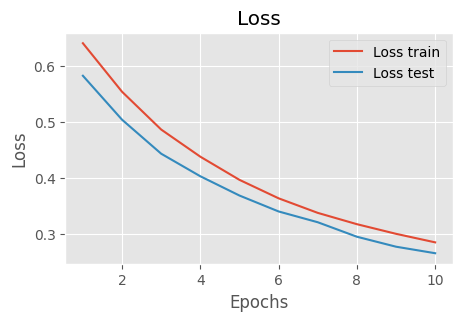

In [ ]:
plt.figure(figsize=(5,3))
plt.plot(np.arange(1,EPOCHS+1), loss_train)
plt.plot(np.arange(1,EPOCHS+1), loss_test)
plt.title('Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Loss train', 'Loss test'])
plt.show()

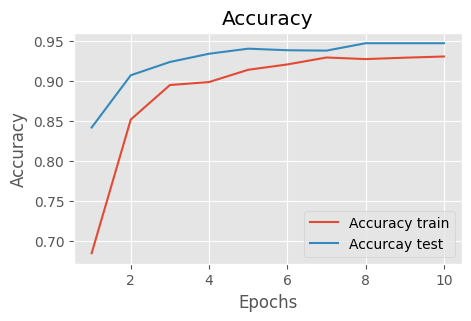

In [ ]:
plt.figure(figsize=(5,3))
plt.plot(np.arange(1,EPOCHS+1), acc_train)
plt.plot(np.arange(1,EPOCHS+1), acc_test)
plt.title('Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Accuracy train', 'Accurcay test'])
plt.show()

## Evaluar el modelo

In [ ]:
y_preds = []
y_true = []
model.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions ..."):
        X = X.to(device)
        # Pasar datos por la red
        y_pred_logs = model(X)
         # Utilizar la función torch.sigmoid para convertir los logs a un valor entre 0 y 1
        y_pred = torch.sigmoid(y_pred_logs)
        y_pred = torch.round(y_pred) # y_pred>0.50 -> y_pred=1 y y_pred<=0.50 -> y_pred=0
        y_preds.append(y_pred.cpu())
        y_true.append(y.cpu())

y_preds = torch.cat(y_preds)
y_true = torch.cat(y_true)

Making predictions ...:   0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
y_true = y_true.numpy()
y_preds = y_preds.numpy()

In [ ]:
cf_matrix = confusion_matrix(y_true, y_preds)

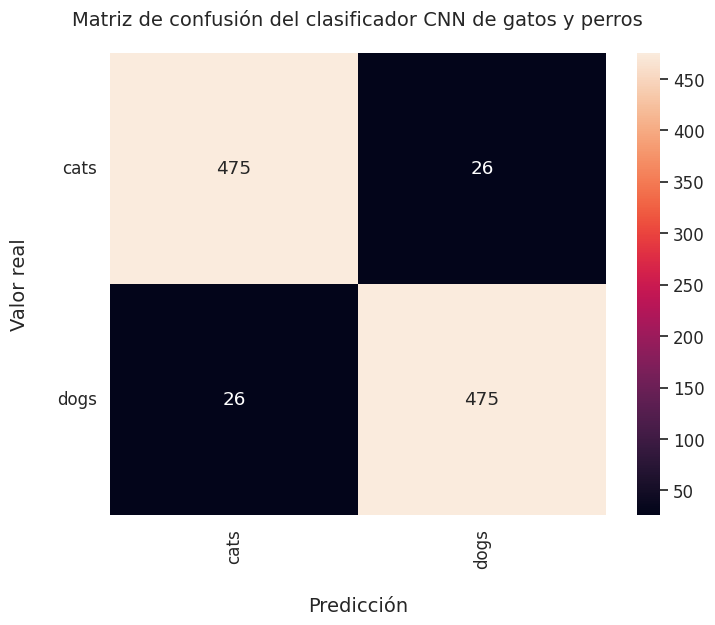

In [ ]:
plt.figure(figsize=(8,6))
# Modificar el tamaño del texto
sns.set(font_scale = 1.1)

# Plot Matriz de confusión con heatmaps
# Parámetros:
# - first param - Matriz de confusión en un formato array
# - annot = True: Muestra los números en cada celda del heatmap
# - fmt = 'd': Muestra los números como enteros.
ax = sns.heatmap(cf_matrix, annot=True, fmt='d', )

# set x-axis label and ticks.
ax.set_xlabel("Predicción", fontsize=14, labelpad=20)
ax.xaxis.set_ticklabels(test_data.classes, rotation=90)

# set y-axis label and ticks
ax.set_ylabel("Valor real", fontsize=14, labelpad=20)
ax.yaxis.set_ticklabels(test_data.classes, rotation=0)

# set plot title
ax.set_title("Matriz de confusión del clasificador CNN de gatos y perros", fontsize=14, pad=20)
plt.show()

In [ ]:
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       501
           1       0.95      0.95      0.95       501

    accuracy                           0.95      1002
   macro avg       0.95      0.95      0.95      1002
weighted avg       0.95      0.95      0.95      1002



## Probar el modelo en datos nunca antes vistos por el modelo

In [ ]:
# Seleccionar las imágenes de prueba al mismo tiempo
uploaded = files.upload()

Saving img3.jpeg to img3.jpeg
Saving img2.jpeg to img2.jpeg
Saving img1.jpeg to img1.jpeg


In [ ]:
def predict_image(model, img_tensor, device="cpu"):
    model = model.to(device)
    model.eval()

    # img_tensor debe tener forma (C, H, W)
    img_tensor = img_tensor.unsqueeze(0).to(device)  # -> (1, C, H, W)

    with torch.no_grad():
        output = model(img_tensor)
        y_pred = torch.sigmoid(output)
        y_class = torch.round(y_pred)

    return y_pred, y_class

In [ ]:
def show_prediction(img_pil):
    plt.imshow(img_pil)
    plt.axis('off')
    plt.show()


Procesando imagen: img3.jpeg


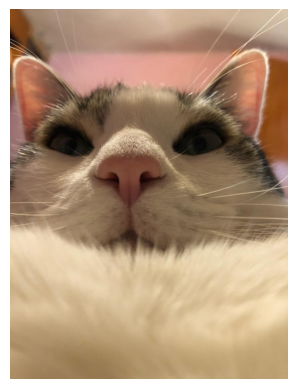

Probabilidad:  tensor([[0.1028]])
Es un Gato!!

Procesando imagen: img2.jpeg


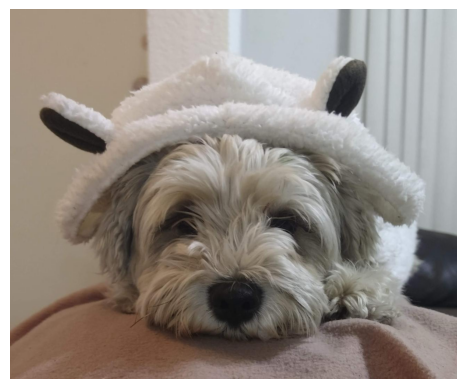

Probabilidad:  tensor([[0.6285]])
Es un Perro!!

Procesando imagen: img1.jpeg


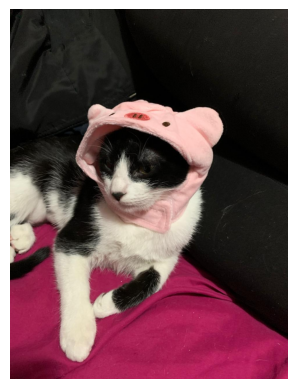

Probabilidad:  tensor([[0.2816]])
Es un Gato!!


In [ ]:
for filename, filedata in uploaded.items():
    print(f"\nProcesando imagen: {filename}")
    # Abrir imagen
    img_pil = Image.open(filename).convert("RGB")
    show_prediction(img_pil)
    # Transformarla
    img_tensor = transformations(img_pil)
    # Predecir
    y_pred, y_class = predict_image(model, img_tensor, device="cpu")
    print("Probabilidad: ",y_pred)
    if int(y_class.item())==0:
        print("Es un Gato!!")
    else:
        print("Es un Perro!!")